# DECODER

In [24]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band', 'envelope_log_onset'])

In [25]:
# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = 'S13'  # pick first subject

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# Store time series for example subject
# ------------------------------------------------
eeg_example = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle')
time_series_example = {}

for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg_example).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]
    time_series_example[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg_example).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]
    time_series_example[f'Univ {model}'] = pred_univ

# true envelope WHAT THE HEEEEEEEEEELL
#TODO: fix this shit
true_env_example = subject_model_predictors[subject_example]['envelope_log'][0].x
time_example = subject_model_predictors[subject_example]['envelope_log'][0].time.times

print("✅ All values computed and stored.")

✅ All values computed and stored.


/var/folders/y0/p95jrf3s35b2tqj_rnj24xjr0000gn/T/ipykernel_95382/2033771159.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


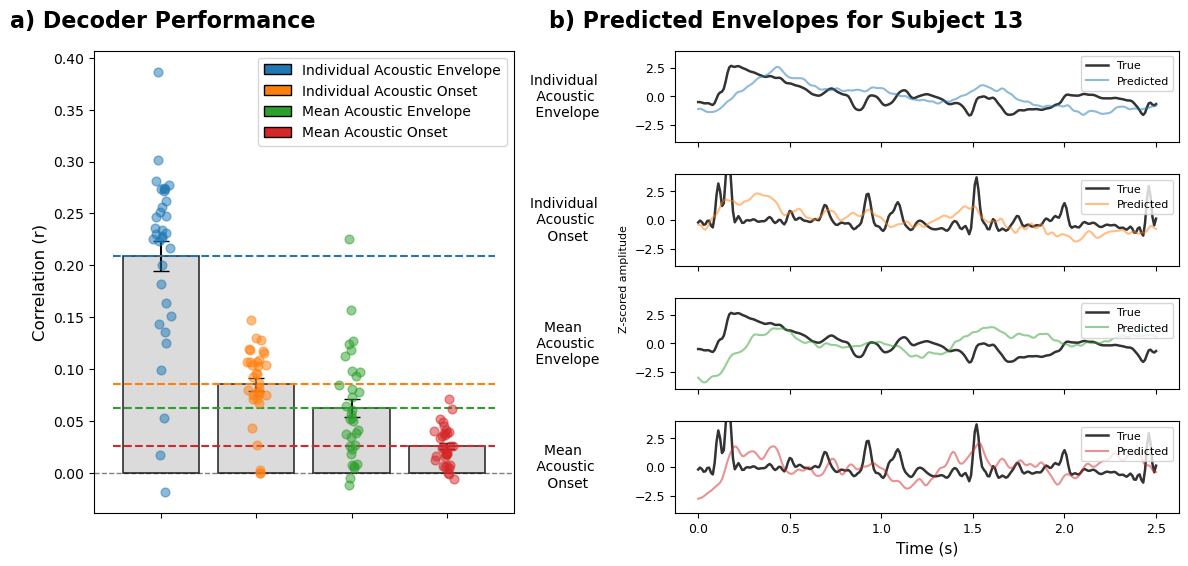

In [26]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec
import seaborn as sns
from matplotlib.patches import Patch

t_max = 2.5  # seconds to show in panel B

# ------------------------------------------------
# Color palette for consistency
# ------------------------------------------------
trace_colors = sns.color_palette("tab10", n_colors=4)  # for panel B traces
label_colors = trace_colors  # map to panel A scatter points
color_alpha = 0.5

# ------------------------------------------------
# PANEL A: Bar plot with grey bars, semi-transparent scatter, horizontal mean lines
# ------------------------------------------------
'''
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
label_name = {'Subj Log': 'Individual Acoustic Envelope', 
              'Subj Onset': 'Individual Acoustic Onset', 
              'Univ Log': 'Mean Acoustic Envelope', 
              'Univ Onset': 'Mean Acoustic Onset'}
'''
labels = ['Individual Acoustic Envelope', 'Individual Acoustic Onset', 'Mean Acoustic Envelope', 'Mean Acoustic Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# Bar plot
ax0 = fig.add_subplot(gs[0])
x = np.arange(len(labels))

# Bars (grey, semi-transparent)
ax0.bar(x, means, yerr=sems, capsize=6, color='lightgrey', edgecolor='k', linewidth=1.2, alpha=0.8, zorder=1)

for i, d in enumerate(data):
    # Horizontal dashed line across the plot at the mean
    ax0.hlines(means[i], xmin=-0.5, xmax=len(labels)-0.5, 
               color=trace_colors[i], linestyle='--', linewidth=1.5, zorder=2)
    
    # Scatter points
    ax0.scatter(np.random.normal(i, 0.05, size=len(d)), d, 
                color=trace_colors[i], alpha=color_alpha, s=40, zorder=3)

ax0.set_xticks(x)
ax0.set_xticklabels([], rotation=25)
ax0.set_ylabel('Correlation (r)', fontsize=12)
#ax0.set_title('Panel A: Decoder Performance', fontsize=14)
ax0.axhline(0, linestyle='--', color='gray', linewidth=1, zorder=0)

# Legend inside panel A (upper right)
legend_elements = [Patch(facecolor=trace_colors[i], edgecolor='k', label=labels[i]) for i in range(4)]
ax0.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Add label "a)"
ax0.text(-0.2, 1.05, 'a) Decoder Performance', transform=ax0.transAxes, fontsize=16, fontweight='bold')

# ------------------------------------------------
# PANEL B: Four stacked mini-plots with z-scored signals and transparency
# ------------------------------------------------

mask = time_example <= t_max
time_50 = time_example[mask]

gs_right = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], hspace=0.35)
plot_keys = ['Subj envelope_log', 'Subj envelope_onset', 'Univ envelope_log', 'Univ envelope_onset']

for i, key in enumerate(plot_keys):
    ax = fig.add_subplot(gs_right[i])
    if 'log' in key.lower():
        pred = time_series_example[f'Subj envelope_log'] if 'Subj' in key else time_series_example[f'Univ envelope_log']
        true_env_example = subject_model_predictors[subject_example]['envelope_log'][0].x
    else:
        pred = time_series_example[f'Subj envelope_onset'] if 'Subj' in key else time_series_example[f'Univ envelope_onset']
        true_env_example = subject_model_predictors[subject_example]['envelope_onset'][0].x
    
    env_50 = true_env_example[mask]

    # z-score standardization
    pred_masked = pred[:len(env_50)]
    pred_z = (pred_masked - np.mean(pred_masked)) / np.std(pred_masked)
    env_z = (env_50 - np.mean(env_50)) / np.std(env_50)

    ax.plot(time_50, env_z, label='True', color='black', linewidth=1.8, alpha=0.8)
    ax.plot(time_50, pred_z, label='Predicted', color=trace_colors[i], linewidth=1.5, alpha=color_alpha)
    
    labels = ['Individual \n Acoustic \n Envelope', 'Individual \n Acoustic \n Onset', 'Mean \n Acoustic \n Envelope', 'Mean \n Acoustic \n Onset']
    ax.set_ylabel(labels[i], rotation=0, labelpad=50, fontsize=10, va='center')
    
    if i == 3:
        ax.set_xlabel('Time (s)', fontsize=11)
    else:
        ax.set_xticklabels([])
    
    ax.set_ylim([-4,4])
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.legend(fontsize=8, loc='upper right')

# Shared y-axis label for all 4 mini-plots
fig.text(0.5, 0.5, 'Z-scored amplitude', va='center', rotation=90, fontsize=8)

# Add label "b)"
ax = fig.add_subplot(gs[1])
ax.text(-0.25, 1.05, 'b) Predicted Envelopes for Subject 13', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.axis('off')  # hide this temporary axis

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


# ENCODER

In [29]:
import eelbrain
import numpy as np

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {
    model: eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle')
    for model in models
}

# ------------------------------------------------
# Loop over subjects
# ------------------------------------------------
for subject in SUBJECTS:

    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:

        predictors = subject_model_predictors[subject][model]

        # ----------------------------------------
        # Subject encoder
        # ----------------------------------------
        trf_sub = eelbrain.load.unpickle(
            TRF_DIR / subject / f'{subject} {model}.pickle'
        )

        pred_sub = eelbrain.convolve(trf_sub.h_scaled, predictors).x

        # flatten both → simple correlation
        r = np.corrcoef(eeg.x.flatten(), pred_sub.flatten())[0,1]
        r_values[model].append(r)

        # ----------------------------------------
        # Universal encoder
        # ----------------------------------------
        trf_univ = universal_trfs[model]

        pred_univ = eelbrain.convolve(trf_univ, predictors[0]).x

        r_univ = np.corrcoef(eeg.x.flatten(), pred_univ.flatten())[0,1]
        r_values_universal[model].append(r_univ)

print("✅ Encoder values computed")


✅ Encoder values computed


/var/folders/y0/p95jrf3s35b2tqj_rnj24xjr0000gn/T/ipykernel_95382/1122908125.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


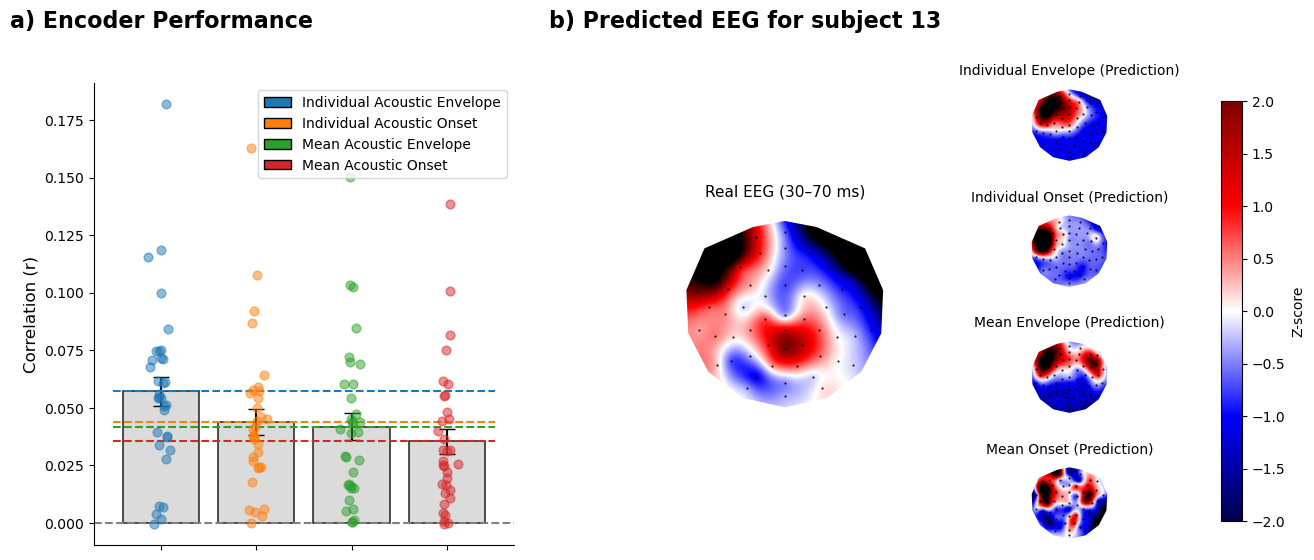

In [30]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec
import seaborn as sns
import numpy as np
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import zscore
from eelbrain import NDVar
import eelbrain

# ------------------------------------------------
# Colors
# ------------------------------------------------
colors = sns.color_palette("tab10", 4)
alpha = 0.5

# ------------------------------------------------
# FIGURE + MASTER GRID
# ------------------------------------------------
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# =================================================
# PANEL A — BAR PLOT
# =================================================
ax0 = fig.add_subplot(gs[0])

labels = [
    'Individual Acoustic Envelope',
    'Individual Acoustic Onset',
    'Mean Acoustic Envelope',
    'Mean Acoustic Onset'
]

data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

x = np.arange(len(labels))

# bars
ax0.bar(
    x, means, yerr=sems, capsize=6,
    color='lightgrey', edgecolor='k',
    linewidth=1.2, alpha=0.8, zorder=1
)

# scatter + mean lines
for i, d in enumerate(data):
    ax0.hlines(
        means[i], -0.5, len(labels)-0.5,
        color=colors[i], linestyle='--',
        linewidth=1.5, zorder=2
    )

    ax0.scatter(
        np.random.normal(i, 0.05, len(d)), d,
        color=colors[i], alpha=alpha,
        s=40, zorder=3
    )

ax0.set_ylabel('Correlation (r)', fontsize=12)
ax0.set_xticks(x)
ax0.set_xticklabels([])

ax0.axhline(0, linestyle='--', color='gray')

# clean look
ax0.spines[['top', 'right']].set_visible(False)

# legend
legend = [Patch(facecolor=colors[i], edgecolor='k', label=labels[i]) for i in range(4)]
ax0.legend(handles=legend, fontsize=10, loc='upper right')

# panel label (raised higher)
ax0.text(
    -0.2, 1.12,
    'a) Encoder Performance',
    transform=ax0.transAxes,
    fontsize=16,
    fontweight='bold'
)

# =================================================
# PANEL B — TOPOMAPS (IMPROVED DESIGN)
# =================================================
gs_right = GridSpecFromSubplotSpec(
    4, 2,
    subplot_spec=gs[1],
    width_ratios=[1, 1],   # keep balanced
    wspace=0.3,
    hspace=0.5
)

subject_example = 'S13'

eeg = eelbrain.load.unpickle(
    STIMULUS_DIR / f'{subject_example}concatenated_eeg.pickle'
)

titles = [
    ('Subj envelope_log', 'Individual Envelope'),
    ('Subj envelope_onset', 'Individual Onset'),
    ('Univ envelope_log', 'Mean Envelope'),
    ('Univ envelope_onset', 'Mean Onset')
]

# shared color scale
vmin, vmax = -2, 2

# -----------------------------------------
# REAL EEG (ONE BIG TOPOMAP)
# -----------------------------------------
tmin, tmax = 0.03, 0.07
time = eeg.time.times
mask = (time >= tmin) & (time <= tmax)

real_window = eeg.x[:, mask].mean(axis=1)
real_z = zscore(real_window)
real_map = NDVar(real_z, dims=(eeg.sensor,))

# span all rows (big plot)
ax_real_big = fig.add_subplot(gs_right[:, 0])

eelbrain.plot.Topomap(real_map, axes=ax_real_big, vmin=vmin, vmax=vmax)
ax_real_big.set_title('Real EEG (30–70 ms)', fontsize=11)

# -----------------------------------------
# PREDICTED MAPS (RIGHT COLUMN)
# -----------------------------------------
for i, (key, label) in enumerate(titles):

    model = key.split()[-1]
    stimulus = subject_model_predictors[subject_example][model]

    # SUBJECT
    if 'Subj' in key:
        trf = eelbrain.load.unpickle(
            TRF_DIR / subject_example / f'{subject_example} {model}.pickle'
        )
        pred = eelbrain.convolve(trf.h_scaled, stimulus)

    # UNIVERSAL
    else:
        trf = eelbrain.load.unpickle(
            TRF_DIR / f'universal-trf-{model}.pickle'
        )
        pred = eelbrain.convolve(trf, stimulus[0])

    pred_window = pred.x[:, mask].mean(axis=1)
    pred_z = zscore(pred_window)
    pred_map = NDVar(pred_z, dims=(pred.sensor,))

    ax_pred = fig.add_subplot(gs_right[i, 1])

    eelbrain.plot.Topomap(pred_map, axes=ax_pred, vmin=vmin, vmax=vmax)
    ax_pred.set_title(f'{label} (Prediction)', fontsize=10)


# ------------------------------------------------
# SHARED COLORBAR
# ------------------------------------------------
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap='seismic' , norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Z-score', fontsize=10)

# ------------------------------------------------
# PANEL B LABEL (raised higher)
# ------------------------------------------------
ax_label = fig.add_subplot(gs[1])
ax_label.text(
    -0.25, 1.12,
    'b) Predicted EEG for subject 13',
    transform=ax_label.transAxes,
    fontsize=16,
    fontweight='bold'
)
ax_label.axis('off')

# ------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------
plt.tight_layout(rect=[0, 0, 0.92, 1])

plt.show()